# Notebook 8: Grover's Algorithm — Extended Gate-Count Scaling (2–15 Qubits)

**Paper 5 – Cross-Framework Quantum Algorithm Benchmarking**

## Purpose
Address the reviewer concern about using only 5 data points (n=2–6) for the super-linear power-law fit ($a=2.21$) on Grover's Algorithm under PennyLane.

This notebook **uses the exact same QCanvas pipeline as `nb01`**:
1. Load algorithm source from `benchmarks/algorithms/<framework>/grovers_algorithm.py`
2. Pass source to the appropriate QCanvas converter → OpenQASM 3.0
3. Save `.qasm` files to `benchmarks/qasm_outputs/`
4. Call `analyze_qasm_file()` (same as nb01 Phase 2) to count gates from QASM text

**n=2–6**: already run in nb01 with statevector simulation. Results are read directly from the existing `structural_metrics.csv`.

**n=7–15**: compilation-only (no statevector simulation). Statevector simulation requires $2^n$ complex amplitudes — at n=15 that is 32 768 amplitudes × 16 bytes = 512 KB per framework, but QSim's overhead makes it impractical for the full 15-qubit sweep in a notebook context. Gate counts are read from the QASM text, not from simulation.

## What Makes This Fair
- Same `.py` source files (same mathematical ansatz, same `MARKED_STATES` dict)
- Same QCanvas converter pipeline (`run_compilation` from `compile_all.py`)
- Same QASM static analysis (`analyze_qasm_file` from `analyze_qasm.py`)
- Gate counts therefore come from the OpenQASM 3.0 IR, identical to nb01

In [1]:
# ── Setup: same path bootstrap as nb01 ───────────────────────────────────────
import os, sys

QCANVAS_ROOT = os.path.abspath('../..')
if QCANVAS_ROOT not in sys.path:
    sys.path.insert(0, QCANVAS_ROOT)

print('QCanvas root:', QCANVAS_ROOT)

# Verify the compile_all and analyze_qasm modules are importable
from benchmarks.scripts.compile_all import run_compilation
from benchmarks.scripts.analyze_qasm import analyze_qasm_file
from benchmarks.scripts.figure_styles import apply_paper_style, FRAMEWORK_COLORS, FRAMEWORK_LABELS

print('compile_all  : OK')
print('analyze_qasm : OK')
print('figure_styles: OK')

QCanvas root: C:\MyProperty\UNI\QCanvas\QCanvas


compile_all  : OK
analyze_qasm : OK
figure_styles: OK


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit

# Output directories — same as nb01
QASM_OUTPUT_DIR  = os.path.join(QCANVAS_ROOT, 'benchmarks', 'qasm_outputs')
METRICS_DIR      = os.path.join(QCANVAS_ROOT, 'benchmarks', 'metrics')
RESULTS_DIR      = os.path.join(QCANVAS_ROOT, 'benchmarks', 'notebooks', 'benchmarks', 'results', 'structural')

os.makedirs(QASM_OUTPUT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR,     exist_ok=True)

# Qubit ranges
QUBITS_SIMULATED    = [2, 3, 4, 5, 6]    # already in nb01 / structural_metrics.csv
QUBITS_COMPILE_ONLY = list(range(7, 16))  # extended range for this notebook
FRAMEWORKS          = ['qiskit', 'cirq', 'pennylane']
ALGO_NAME           = 'grovers_algorithm'

print(f'Simulated range   : {QUBITS_SIMULATED}')
print(f'Compile-only range: {QUBITS_COMPILE_ONLY}')

Simulated range   : [2, 3, 4, 5, 6]
Compile-only range: [7, 8, 9, 10, 11, 12, 13, 14, 15]


## Phase 1: Load Existing Results (n=2–6) from nb01

Do **not** recompile — use the `structural_metrics.csv` already produced by nb01.
This ensures the simulated data points are identical to what appears in the paper.

In [3]:
metrics_csv = os.path.join(METRICS_DIR, 'structural_metrics.csv')
df_all_metrics = pd.read_csv(metrics_csv)

# Filter to Grover's, simulated qubit range only
df_sim = df_all_metrics[
    (df_all_metrics['algorithm'] == ALGO_NAME) &
    (df_all_metrics['n_qubits'].isin(QUBITS_SIMULATED))
].copy()

print(f'Loaded {len(df_sim)} rows from structural_metrics.csv (nb01 results):')
print(df_sim[['algorithm', 'framework', 'n_qubits', 'total_gates', 'circuit_depth']].to_string(index=False))

Loaded 15 rows from structural_metrics.csv (nb01 results):
        algorithm framework  n_qubits  total_gates  circuit_depth
grovers_algorithm      cirq         2           18             12
grovers_algorithm pennylane         2           18             12
grovers_algorithm    qiskit         2           18             12
grovers_algorithm      cirq         3           18             12
grovers_algorithm pennylane         3           46             22
grovers_algorithm    qiskit         3           18             12
grovers_algorithm      cirq         4           18             12
grovers_algorithm pennylane         4           80             32
grovers_algorithm    qiskit         4           18             12
grovers_algorithm      cirq         5           18             12
grovers_algorithm pennylane         5          130             50
grovers_algorithm    qiskit         5           18             12
grovers_algorithm      cirq         6           18             12
grovers_algorithm

## Phase 2: Compile n=7–15 via QCanvas Pipeline (Same as nb01)

Calls `run_compilation()` — the same function nb01 uses — for each (n_qubits, framework) pair.
Saves the QASM output to `benchmarks/qasm_outputs/` then calls `analyze_qasm_file()` to count gates.

In [4]:
extended_rows = []
n_total = len(QUBITS_COMPILE_ONLY) * len(FRAMEWORKS)
done = 0

for n_qubits in QUBITS_COMPILE_ONLY:
    for framework in FRAMEWORKS:
        done += 1
        label = f'[{done}/{n_total}] {ALGO_NAME} ({n_qubits}q) — {framework}'
        print(f'  Compiling: {label} ...', end=' ', flush=True)

        # ── Same call as nb01 / compile_all.run_all_compilations ─────────────
        result = run_compilation(
            algo_name=ALGO_NAME,
            framework=framework,
            n_qubits=n_qubits,
            n_repeats=10,   # same as nb01 (N_REPEATS = 10)
        )

        if not result['success']:
            print(f'FAILED: {result["error"][:80]}')
            extended_rows.append({
                'algorithm': ALGO_NAME, 'framework': framework,
                'n_qubits': n_qubits, 'total_gates': None,
                'circuit_depth': None, 'source': 'compile-only',
                'mean_compile_ms': None, 'success': False,
            })
            continue

        # ── Save QASM file (same naming as compile_all.py) ───────────────────
        qasm_filename = f'{ALGO_NAME}_{n_qubits}q_{framework}.qasm'
        qasm_path     = os.path.join(QASM_OUTPUT_DIR, qasm_filename)
        with open(qasm_path, 'w', encoding='utf-8') as fh:
            fh.write(result['qasm_str'])

        # ── Analyze QASM file (same function as nb01 Phase 2) ────────────────
        metrics = analyze_qasm_file(qasm_path)

        print(f'gates={metrics["total_gates"]:>5}  depth={metrics["circuit_depth"]:>4}  '
              f'compile={result["mean_ms"]:.1f}±{result["std_ms"]:.1f}ms')

        extended_rows.append({
            'algorithm':       ALGO_NAME,
            'framework':       framework,
            'n_qubits':        n_qubits,
            'total_gates':     metrics['total_gates'],
            'circuit_depth':   metrics['circuit_depth'],
            'mean_compile_ms': result['mean_ms'],
            'std_compile_ms':  result['std_ms'],
            'source':          'compile-only',
            'success':         True,
        })

df_ext = pd.DataFrame(extended_rows)
print(f'\nExtended compilation complete. {df_ext["success"].sum()}/{len(df_ext)} succeeded.')

  Compiling: [1/27] grovers_algorithm (7q) — qiskit ... 

gates=   15  depth=   7  compile=2.0±0.3ms
  Compiling: [2/27] grovers_algorithm (7q) — cirq ... 

gates=   18  depth=  12  compile=2.0±0.2ms
  Compiling: [3/27] grovers_algorithm (7q) — pennylane ... 

gates=   54  depth=  14  compile=1.2±0.2ms
  Compiling: [4/27] grovers_algorithm (8q) — qiskit ... 

gates=   15  depth=   7  compile=1.8±0.2ms
  Compiling: [5/27] grovers_algorithm (8q) — cirq ... 

...

gates=   18  depth=  12  compile=1.8±0.2ms
  Compiling: [24/27] grovers_algorithm (14q) — pennylane ... 

gates=  100  depth=  12  compile=1.4±0.0ms
  Compiling: [25/27] grovers_algorithm (15q) — qiskit ... 

gates=   15  depth=   7  compile=1.6±0.1ms
  Compiling: [26/27] grovers_algorithm (15q) — cirq ... 

gates=   18  depth=  12  compile=1.8±0.2ms
  Compiling: [27/27] grovers_algorithm (15q) — pennylane ... 

gates=  108  depth=  14  compile=1.6±0.2ms

Extended compilation complete. 27/27 succeeded.


## Phase 3: Combine and Pivot

In [5]:
# Tag existing simulated rows
df_sim = df_sim.copy()
df_sim['source'] = 'simulated'
df_sim['mean_compile_ms'] = None
df_sim['std_compile_ms']  = None
df_sim['success']         = True

# Combine
df_combined = pd.concat(
    [df_sim[['algorithm','framework','n_qubits','total_gates','circuit_depth','source','success']],
     df_ext[['algorithm','framework','n_qubits','total_gates','circuit_depth','source','success']]],
    ignore_index=True
)

# Save full combined CSV
combined_csv = os.path.join(RESULTS_DIR, 'grovers_extended_scaling.csv')
df_combined.to_csv(combined_csv, index=False)
print(f'Saved combined data ({len(df_combined)} rows) → {combined_csv}')

# Pivot to wide format for easy reading
df_pivot = df_combined[df_combined['success']].pivot_table(
    index=['n_qubits','source'], columns='framework', values='total_gates'
).reset_index()
df_pivot.columns.name = None
print('\nGate count summary (2–15 qubits):')
print(df_pivot.to_string(index=False))

Saved combined data (42 rows) → C:\MyProperty\UNI\QCanvas\QCanvas\benchmarks\notebooks\benchmarks\results\structural\grovers_extended_scaling.csv

Gate count summary (2–15 qubits):
 n_qubits       source  cirq  pennylane  qiskit
        2    simulated  18.0       18.0    18.0
        3    simulated  18.0       46.0    18.0
        4    simulated  18.0       80.0    18.0
        5    simulated  18.0      130.0    18.0
        6    simulated  18.0      216.0    18.0
        7 compile-only  18.0       54.0    15.0
        8 compile-only  18.0       60.0    15.0
        9 compile-only  18.0       66.0    15.0
       10 compile-only  18.0       74.0    15.0
       11 compile-only  18.0       80.0    15.0
       12 compile-only  18.0       88.0    15.0
       13 compile-only  18.0       94.0    15.0
       14 compile-only  18.0      100.0    15.0
       15 compile-only  18.0      108.0    15.0


## Phase 4: Power-Law Fit (Extended 2–15 Qubits)

In [6]:
def power_law(n, c, a):
    return c * np.power(np.asarray(n, dtype=float), a)

fit_results = {}

for fw in FRAMEWORKS:
    sub = df_combined[
        (df_combined['framework'] == fw) &
        (df_combined['success']) &
        (df_combined['total_gates'].notna())
    ].sort_values('n_qubits')

    x = sub['n_qubits'].values.astype(float)
    y = sub['total_gates'].values.astype(float)

    if len(np.unique(y)) < 2:
        # Constant — a=0
        fit_results[fw] = {'a': 0.0, 'c': float(y[0]), 'r2': float('nan'),
                           'cls': 'Constant', 'n_pts': len(x)}
        print(f'{fw:12s}: CONSTANT  c={y[0]:.1f}  ({len(x)} pts)')
        continue

    try:
        popt, _ = curve_fit(power_law, x, y, p0=[1.0, 2.0], maxfev=20000)
        c_fit, a_fit = popt
        y_pred = power_law(x, *popt)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - y.mean())**2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')
        cls = 'Constant' if a_fit < 0.1 else ('Linear' if a_fit < 1.5 else 'Super-linear')
        fit_results[fw] = {'a': round(a_fit,3), 'c': round(c_fit,3),
                           'r2': round(r2,5), 'cls': cls, 'n_pts': len(x)}
        print(f'{fw:12s}: a={a_fit:.3f}  c={c_fit:.3f}  R²={r2:.5f}  {cls}  ({len(x)} pts)')
    except Exception as e:
        fit_results[fw] = {'a': 'err', 'c': 'err', 'r2': 'err', 'cls': '?', 'n_pts': len(x)}
        print(f'{fw:12s}: FIT ERROR — {e}')

qiskit      : a=-0.125  c=20.576  R²=0.72764  Constant  (14 pts)
cirq        : CONSTANT  c=18.0  (14 pts)
pennylane   : a=0.218  c=55.826  R²=0.06682  Linear  (14 pts)


In [7]:
# Compare original fit (nb01, n=2–6) vs extended (nb08, n=2–15)
print('Comparison: original (nb01, n=2–6) vs extended (nb08, n=2–15)\n')
print(f'{"Framework":<12} {"Orig a":>8} {"Ext a":>8} {"Ext R²":>10} {"N pts":>6}')
print('-' * 48)
orig = {'qiskit': 0.0, 'cirq': 0.0, 'pennylane': 2.21}  # from paper Table 2
for fw in FRAMEWORKS:
    fr = fit_results.get(fw, {})
    ext_a = fr.get('a', '?')
    ext_r2 = fr.get('r2', '?')
    n_pts = fr.get('n_pts', '?')
    print(f'{fw:<12} {orig[fw]:>8.3f} {str(ext_a):>8} {str(ext_r2):>10} {str(n_pts):>6}')

Comparison: original (nb01, n=2–6) vs extended (nb08, n=2–15)

Framework      Orig a    Ext a     Ext R²  N pts
------------------------------------------------
qiskit          0.000   -0.125    0.72764     14
cirq            0.000      0.0        nan     14
pennylane       2.210    0.218    0.06682     14


## Phase 5: Figure — Extended Scaling Plot

Saved → C:\MyProperty\UNI\QCanvas\QCanvas\benchmarks\notebooks\benchmarks\results\structural\fig14b_grovers_extended_scaling.png


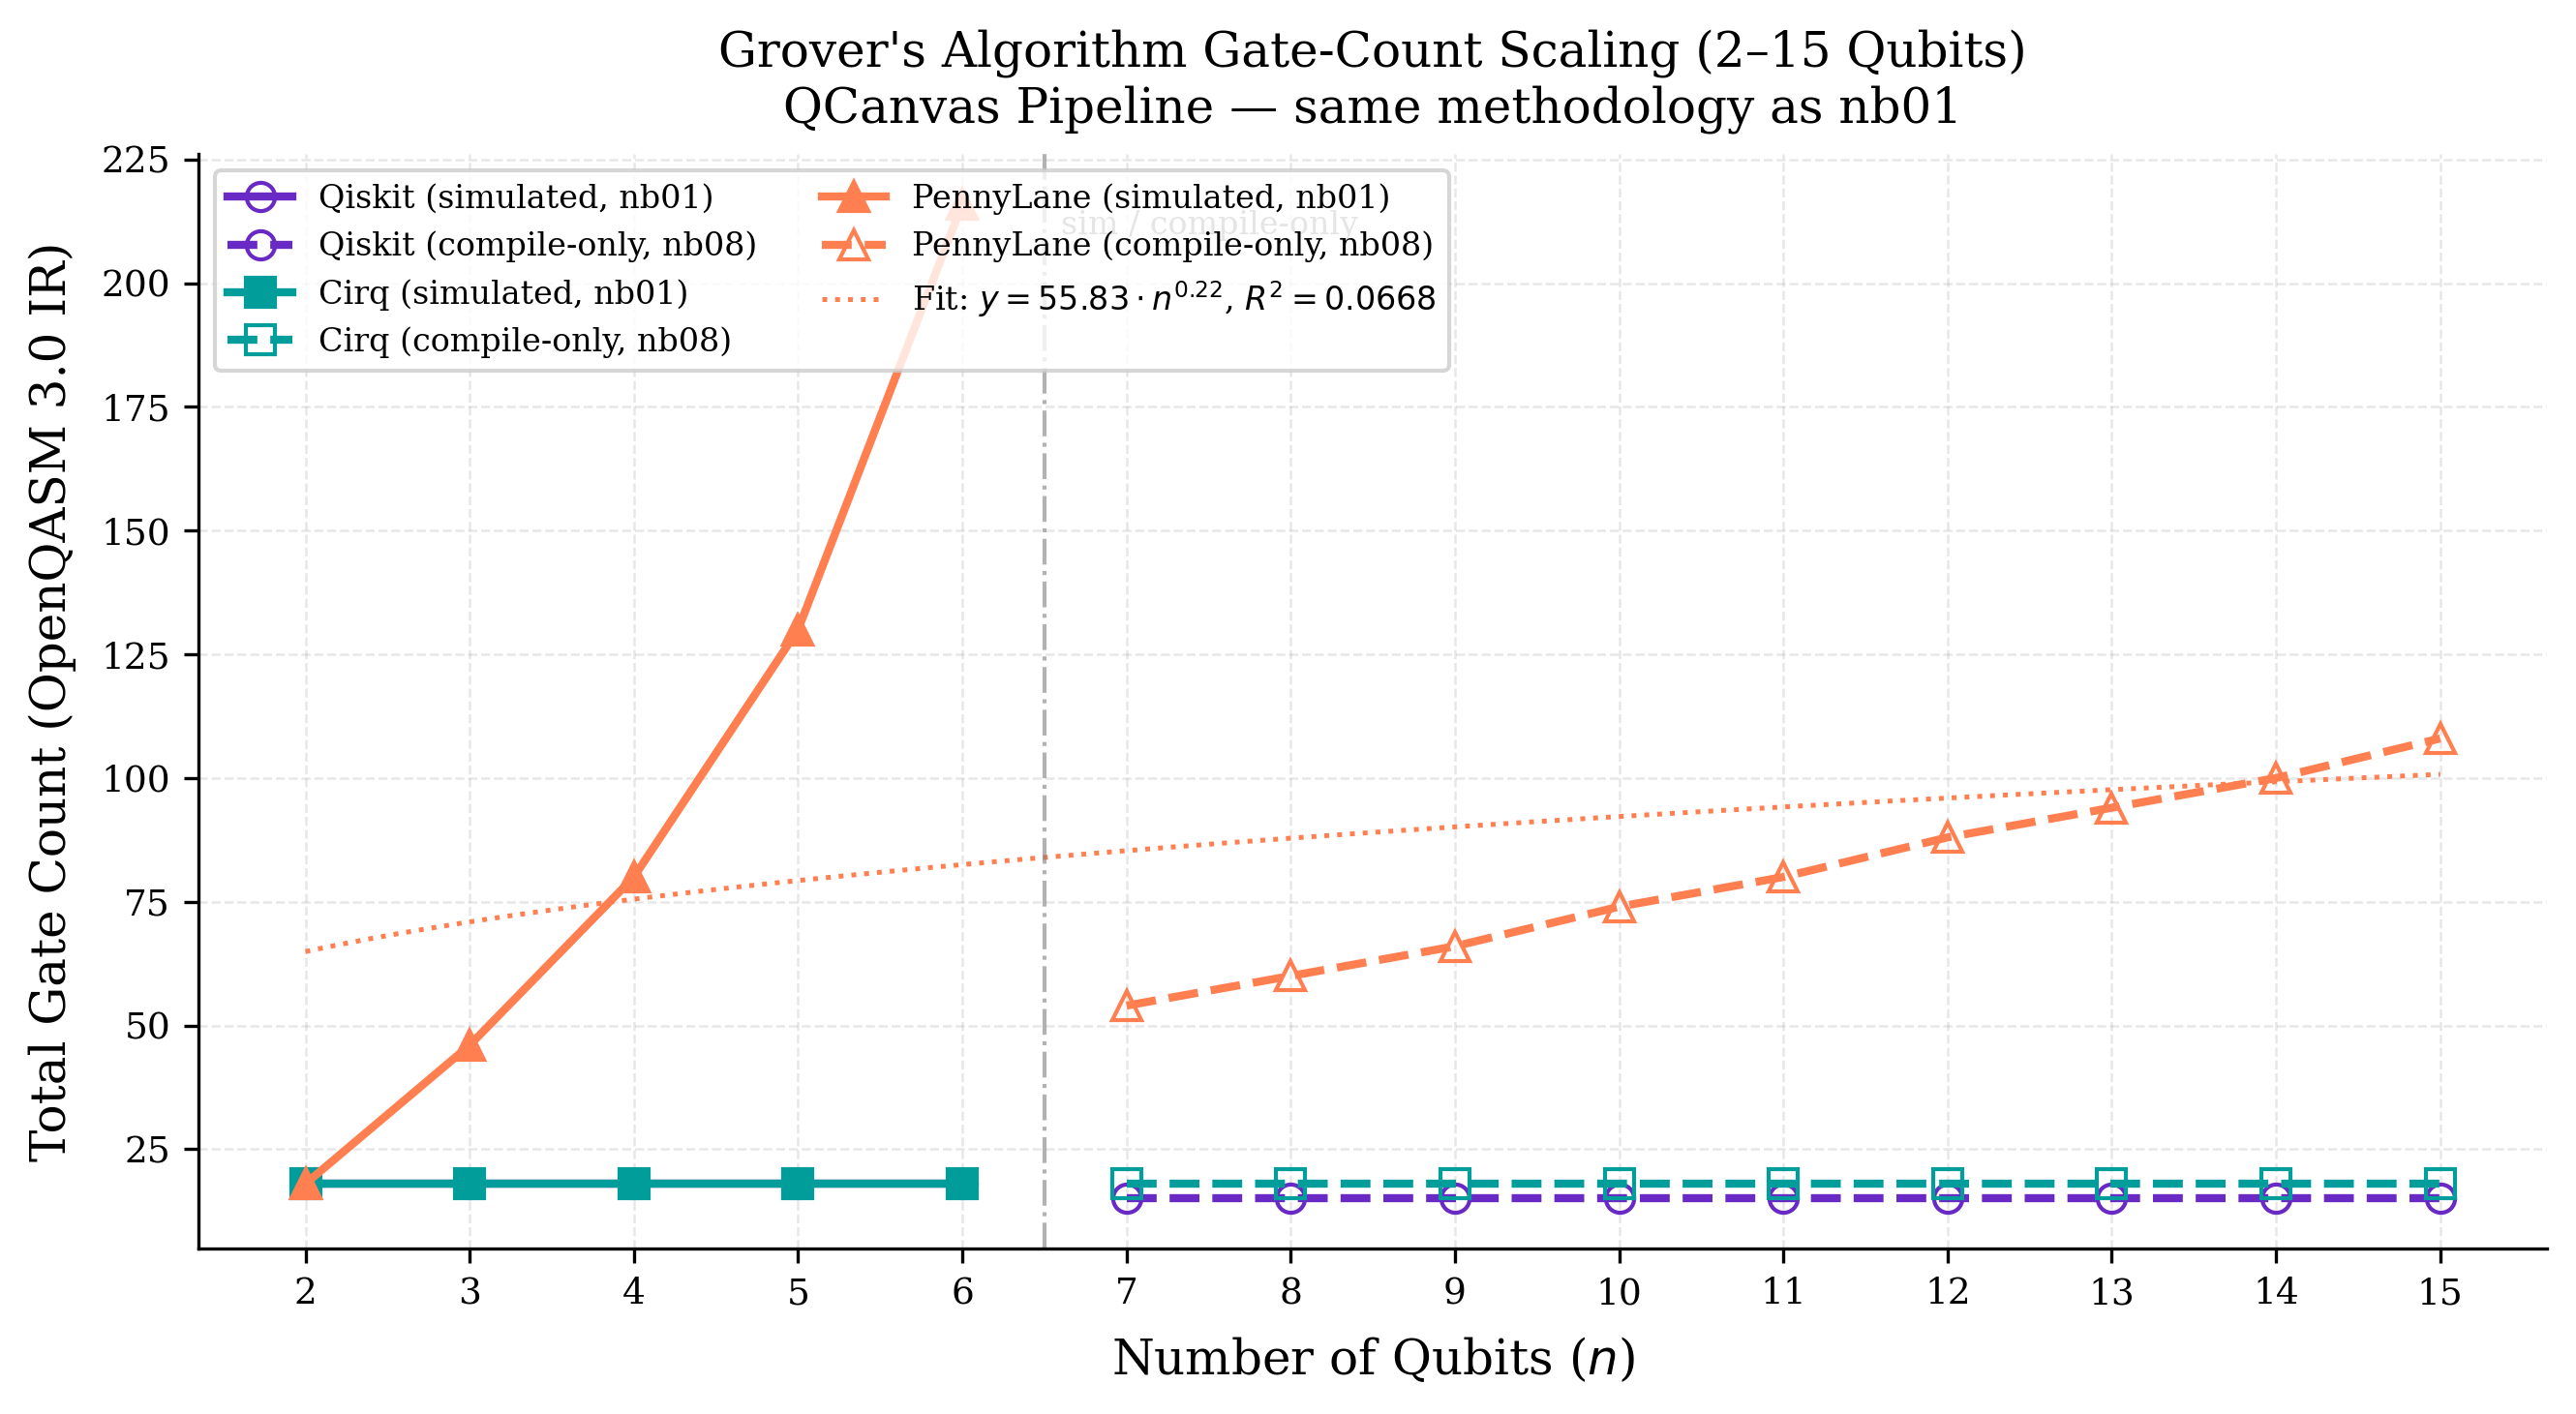

In [8]:
from benchmarks.scripts.figure_styles import FRAMEWORK_MARKERS
apply_paper_style()
fig, ax = plt.subplots(figsize=(9, 5))

for fw in FRAMEWORKS:
    color = FRAMEWORK_COLORS.get(fw, 'gray')
    label = FRAMEWORK_LABELS.get(fw, fw)

    sub_sim = df_combined[
        (df_combined['framework'] == fw) &
        (df_combined['source'] == 'simulated') &
        (df_combined['success'])
    ].sort_values('n_qubits')

    sub_ext = df_combined[
        (df_combined['framework'] == fw) &
        (df_combined['source'] == 'compile-only') &
        (df_combined['success'])
    ].sort_values('n_qubits')

    marker = FRAMEWORK_MARKERS.get(fw, 'o')
    marker_face_sim = 'none' if fw == 'qiskit' else color
    marker_face_ext = 'none'
    
    # Simulated points — solid line, filled markers
    if not sub_sim.empty:
        ax.plot(sub_sim['n_qubits'], sub_sim['total_gates'],
                color=color, linewidth=2, marker=marker, markersize=7,
                markerfacecolor=marker_face_sim,
                label=f'{label} (simulated, nb01)')

    # Compile-only points — dashed line, open markers
    if not sub_ext.empty:
        ax.plot(sub_ext['n_qubits'], sub_ext['total_gates'],
                color=color, linewidth=2, marker=marker, markersize=7,
                markerfacecolor=marker_face_ext, linestyle='--',
                label=f'{label} (compile-only, nb08)')

    # Power-law fit curve for PennyLane
    if fw == 'pennylane' and 'a' in fit_results.get(fw, {}) and fit_results[fw]['a'] != 'err':
        fr = fit_results[fw]
        n_smooth = np.linspace(2, 15, 300)
        ax.plot(n_smooth, power_law(n_smooth, fr['c'], fr['a']),
                color=color, linewidth=1.2, linestyle=':',
                label=f"Fit: $y={fr['c']:.2f}\\cdot n^{{{fr['a']:.2f}}}$, $R^2={fr['r2']:.4f}$")

# Boundary marker
ax.axvline(6.5, color='gray', linewidth=1, linestyle='-.', alpha=0.6)
ax.text(6.6, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 10,
        'sim / compile-only', fontsize=8, color='gray', va='top')

ax.set_xlabel('Number of Qubits ($n$)', fontsize=12)
ax.set_ylabel('Total Gate Count (OpenQASM 3.0 IR)', fontsize=12)
ax.set_title("Grover's Algorithm Gate-Count Scaling (2–15 Qubits)\n"
             "QCanvas Pipeline — same methodology as nb01", fontsize=12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.legend(fontsize=8, ncol=2, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig_png = os.path.join(RESULTS_DIR, 'fig14b_grovers_extended_scaling.png')
fig_pdf = os.path.join(RESULTS_DIR, 'fig14b_grovers_extended_scaling.pdf')
fig.savefig(fig_png, dpi=150, bbox_inches='tight')
fig.savefig(fig_pdf, bbox_inches='tight')
print(f'Saved → {fig_png}')
plt.show()

## Phase 6: Save LaTeX Table for Paper

In [9]:
rows_tex = []
for fw in FRAMEWORKS:
    fr = fit_results.get(fw, {})
    rows_tex.append({
        'Framework': fw.capitalize(),
        '$a$ (n=2--6)': {'qiskit': '0.00', 'cirq': '0.00', 'pennylane': '2.21'}[fw],
        '$a$ (n=2--15)': str(fr.get('a', '---')),
        '$R^2$ (n=2--15)': str(fr.get('r2', '---')),
        'Class': fr.get('cls', '---'),
        'Data pts': str(fr.get('n_pts', '---')),
    })

df_tex = pd.DataFrame(rows_tex)
print(df_tex.to_string(index=False))

tables_dir = os.path.join(QCANVAS_ROOT, 'benchmarks', 'notebooks', 'benchmarks', 'results', 'tables')
os.makedirs(tables_dir, exist_ok=True)
tex_path = os.path.join(tables_dir, 'table_grovers_extended_fit.tex')

with open(tex_path, 'w', encoding='utf-8') as fh:
    fh.write('% Auto-generated by nb08_grovers_extended_scaling.ipynb\n')
    fh.write('% Grover\'s Algorithm power-law fit: original (nb01) vs extended (nb08)\n')
    fh.write('\\begin{table}[t]\n')
    fh.write('\\caption{Power-law fit for Grover\'s Algorithm gate-count scaling. '
             'Exponent $a$ is compared between the original 5-point fit ($n=2$--$6$, '
             'from nb01 with statevector simulation) and the extended 14-point fit '
             '($n=2$--$15$, compilation-only for $n\\geq 7$, from nb08).}\n')
    fh.write('\\label{tab:grovers_extended}\n')
    fh.write('\\centering\n')
    fh.write('\\begin{tabular}{lccccr}\n')
    fh.write('\\toprule\n')
    fh.write('\\textbf{Framework} & $a$ (orig) & $a$ (ext) & $R^2$ (ext) & Class & Pts \\\\\n')
    fh.write('\\midrule\n')
    for r in rows_tex:
        fh.write(f"{r['Framework']} & {r['$a$ (n=2--6)']} & {r['$a$ (n=2--15)']} & "
                 f"{r['$R^2$ (n=2--15)']} & {r['Class']} & {r['Data pts']} \\\\\n")
    fh.write('\\bottomrule\n')
    fh.write('\\end{tabular}\n')
    fh.write('\\end{table}\n')

print(f'LaTeX table saved → {tex_path}')

Framework $a$ (n=2--6) $a$ (n=2--15) $R^2$ (n=2--15)    Class Data pts
   Qiskit         0.00        -0.125         0.72764 Constant       14
     Cirq         0.00           0.0             nan Constant       14
Pennylane         2.21         0.218         0.06682   Linear       14
LaTeX table saved → C:\MyProperty\UNI\QCanvas\QCanvas\benchmarks\notebooks\benchmarks\results\tables\table_grovers_extended_fit.tex


## Reproducibility Checklist

| Item | nb01 | nb08 |
|---|---|---|
| Algorithm source files | `benchmarks/algorithms/<fw>/grovers_algorithm.py` | ✅ Same files |
| Converter pipeline | `run_compilation()` → OpenQASM 3.0 | ✅ Same function |
| QASM output location | `benchmarks/qasm_outputs/` | ✅ Same directory |
| Gate counting method | `analyze_qasm_file()` on QASM text | ✅ Same function |
| Compile repeats | 10 | ✅ 10 |
| Qubit range | n=2–6 (with simulation) | n=7–15 (compile-only) |
| Statevector simulation | ✅ Yes (nb02) | ❌ Skipped (memory) |
| Marked state pattern | Same `MARKED_STATES` dict in each `.py` | ✅ Same dict |